Semana 5 Día 2

### AutoGen AgentChat - Profundizando..

1. Conversación multimodal
2. Salidas estructuradas
3. Usando herramientas LangChain
4. Equipos

...y una sorpresa especial extra

In [1]:
# Importar bibliotecas necesarias para conversación multimodal
from io import BytesIO
import requests
from autogen_agentchat.messages import TextMessage, MultiModalMessage
from autogen_core import Image as AGImage
from PIL import Image
from dotenv import load_dotenv
from autogen_ext.models.openai import OpenAIChatCompletionClient
from autogen_agentchat.agents import AssistantAgent
from autogen_core import CancellationToken
from IPython.display import display, Markdown
from pydantic import BaseModel, Field
from typing import Literal

load_dotenv(override=True)

True

### Una conversación multimodal


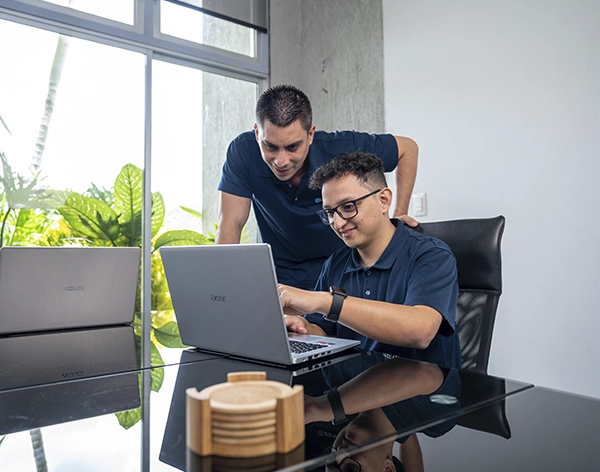

In [2]:
# Descargar imagen de URL y abrirla con PIL
url = "https://edwarddonner.com/wp-content/uploads/2024/10/from-software-engineer-to-AI-DS.jpeg"
url = "https://www.zewsweb.com/wp-content/uploads/2025/05/incio-3.webp"

pil_image = Image.open(BytesIO(requests.get(url).content))
img = AGImage(pil_image)
img

In [3]:
# Crear mensaje multimodal con texto e imagen
multi_modal_message = MultiModalMessage(content=["Describe el contenido de esta imagen con detalle", img], source="User")

In [4]:
# Crear cliente de modelo y agente para describir imágenes
model_client = OpenAIChatCompletionClient(model="gpt-4o-mini")

describer = AssistantAgent(
    name="description_agent",
    model_client=model_client,
    system_message="Se te da bien describir imágenes. Describe la imagen que te doy con mucho detalle, incluyendo objetos, colores, personas, emociones, etc. Si no puedes describir algo con certeza, dilo claramente.",
)

response = await describer.on_messages([multi_modal_message], cancellation_token=CancellationToken())
reply = response.chat_message.content
display(Markdown(reply))

En la imagen se puede observar a dos hombres en un entorno de oficina moderno. Ambos están sentados detrás de una mesa de cristal negro, que refleja parte del ambiente. A la izquierda, hay dos laptops apagadas, una de marca ASUS y otra sin etiqueta visible.

El hombre de pie, que tiene el cabello corto y usa una camiseta azul, se inclina ligeramente hacia adelante, observando al otro hombre con una expresión de interés y atención. El otro hombre, sentado, lleva gafas y también viste una camiseta azul, con un smartwatch en su muñeca izquierda. Está concentrado en la pantalla de su laptop Acer, que está abierta frente a él.

Detrás de ellos, hay grandes ventanales que permiten la entrada de luz natural, y se pueden ver algunas plantas verdes al aire libre, sugiriendo un ambiente refrescante y luminoso. En la mesa, además de las laptops, hay un pequeño objeto de madera, probablemente un soporte o un organizador.

La escena irradia un aire de colaboración y trabajo en equipo, dado el enfoque de ambos hombres en la tarea que tienen delante.

### Salidas estructuradas!

AutoGen AgentChat hace que sea fácil.

In [5]:
# Definir modelo Pydantic para descripción estructurada de imagen
class ImageDescription(BaseModel):
    scene: str = Field(description="En resumen, la escena general de la imagen")
    message: str = Field(description="El mensaje que la imagen intenta transmitir")
    style: str = Field(description="El estilo artístico de la imagen")
    orientation: Literal["retrato", "paisaje", "cuadrado"] = Field(description="La orientación de la imagen")

In [6]:
# Crear agente con salida estructurada para describir imágenes
model_client = OpenAIChatCompletionClient(model="gpt-4o-mini")

describer = AssistantAgent(
    name="description_agent",
    model_client=model_client,
    system_message="Se te da bien describir imágenes con detalle y también estructurar esa descripción de forma clara. Describe la imagen que te doy con mucho detalle, incluyendo objetos, colores, personas, emociones, etc. Si no puedes describir algo con certeza, dilo claramente. Estructura tu respuesta usando el modelo ImageDescription que te doy.",
    output_content_type=ImageDescription,
)

response = await describer.on_messages([multi_modal_message], cancellation_token=CancellationToken())
reply = response.chat_message.content
reply

ImageDescription(scene='La imagen muestra a dos personas en un entorno de oficina moderna. Uno de ellos está sentado frente a un laptop abierto en una mesa de vidrio, mientras que el otro está de pie detrás de él, observando la pantalla. La habitación tiene grandes ventanas que permiten la entrada de luz natural y hay plantas verdes visibles fuera. La mesa tiene tres laptops en total, y en el centro, hay un objeto de madera, probablemente un porta-lápices. Ambos hombres visten camisetas de color azul oscuro.', message='La escena sugiere un ambiente colaborativo y de trabajo en equipo, donde ambos están concentrados en una tarea conjunta. La mirada del hombre sentado indica que está enfocado en lo que está haciendo, mientras que el hombre de pie parece estar ofreciendo asistencia o supervisión.', style='Fotografía contemporánea, con un enfoque en el ambiente laboral y la colaboración entre colegas.', orientation='paisaje')

In [7]:
# Imprimir detalles de la descripción estructurada
import textwrap
print(f"Scene:\n{textwrap.fill(reply.scene)}\n\n")
print(f"Message:\n{textwrap.fill(reply.message)}\n\n")
print(f"Style:\n{textwrap.fill(reply.style)}\n\n")
print(f"Orientation:\n{textwrap.fill(reply.orientation)}\n\n")

Scene:
La imagen muestra a dos personas en un entorno de oficina moderna. Uno
de ellos está sentado frente a un laptop abierto en una mesa de
vidrio, mientras que el otro está de pie detrás de él, observando la
pantalla. La habitación tiene grandes ventanas que permiten la entrada
de luz natural y hay plantas verdes visibles fuera. La mesa tiene tres
laptops en total, y en el centro, hay un objeto de madera,
probablemente un porta-lápices. Ambos hombres visten camisetas de
color azul oscuro.


Message:
La escena sugiere un ambiente colaborativo y de trabajo en equipo,
donde ambos están concentrados en una tarea conjunta. La mirada del
hombre sentado indica que está enfocado en lo que está haciendo,
mientras que el hombre de pie parece estar ofreciendo asistencia o
supervisión.


Style:
Fotografía contemporánea, con un enfoque en el ambiente laboral y la
colaboración entre colegas.


Orientation:
paisaje




### Usando herramientas LangChain desde AutoGen

In [8]:
# Adaptador de AutoGen para herramientas LangChain
from autogen_ext.tools.langchain import LangChainToolAdapter

# Herramientas LangChain
from langchain_community.utilities import GoogleSerperAPIWrapper
from langchain_community.agent_toolkits import FileManagementToolkit
from langchain.agents import Tool

# Prompt para buscar vuelos
prompt = """Tu tarea consiste en encontrar un vuelo de ida sin escalas de San Jose a El Salvador en julio de 2026.
Primero, busca en Internet ofertas interesantes. A continuación, anota todas las ofertas en un archivo llamado flights.md con todos los detalles.
Por último, selecciona la que te parezca mejor y responde con un breve resumen. Responde indicando únicamente el vuelo seleccionado, y solo después de haber anotado los detalles en el archivo."""

# Configurar herramienta de búsqueda
serper = GoogleSerperAPIWrapper()
langchain_serper =Tool(name="internet_search", func=serper.run, description="útil para cuando necesitas buscar en Internet")
autogen_serper = LangChainToolAdapter(langchain_serper)
autogen_tools = [autogen_serper]

# Agregar herramientas de gestión de archivos
langchain_file_management_tools = FileManagementToolkit(root_dir="sandbox").get_tools()
for tool in langchain_file_management_tools:
    autogen_tools.append(LangChainToolAdapter(tool))

for tool in autogen_tools:
    print(tool.name, tool.description)

# Crear agente con herramientas
model_client = OpenAIChatCompletionClient(model="gpt-4o-mini")
agent = AssistantAgent(name="searcher", model_client=model_client, tools=autogen_tools, reflect_on_tool_use=True)
message = TextMessage(content=prompt, source="user")
result = await agent.on_messages([message], cancellation_token=CancellationToken())
for message in result.inner_messages:
    print(message.content)
display(Markdown(result.chat_message.content))

internet_search útil para cuando necesitas buscar en Internet
copy_file Create a copy of a file in a specified location
file_delete Delete a file
file_search Recursively search for files in a subdirectory that match the regex pattern
move_file Move or rename a file from one location to another
read_file Read file from disk
write_file Write file to disk
list_directory List files and directories in a specified folder
[FunctionCall(id='call_HrxyHKkq9LVQQ0VX3aRdPvtz', arguments='{"query":"flights from San Jose to El Salvador non-stop July 2026"}', name='internet_search')]
[FunctionExecutionResult(content="On average, there are around 6 nonstop flights per day from Juan Santamaria Intl. (SJO) to El Salvador Intl. (SAL). For more options, look at flights that ... Missing: July | Show results with:July. There are no airlines offering direct flights. There is 1 airport in San Salvador. From San José there are direct flights to San Salvador El ... Missing: non- July. There are no flights flying

Parece que no hay información disponible sobre vuelos directos de San José a El Salvador para julio de 2026 en este momento. La búsqueda no produjo vuelos específicos, y no se encontraron ofertas concretas. 

TE TERMINO.

In [9]:
# Continuar con el agente para escribir el archivo
message = TextMessage(content="OK proceed", source="user")

result = await agent.on_messages([message], cancellation_token=CancellationToken())
for message in result.inner_messages:
    print(message.content)
display(Markdown(result.chat_message.content))

[FunctionCall(id='call_Slggr9RstfMTSYde89r41Dep', arguments='{"file_path":"flights.md","text":"No hay información disponible sobre vuelos directos de San José a El Salvador para julio de 2026 en este momento. La búsqueda no produjo resultados específicos y no se encontraron ofertas concretas.","append":false}', name='write_file')]
[FunctionExecutionResult(content='File written successfully to flights.md.', name='write_file', call_id='call_Slggr9RstfMTSYde89r41Dep', is_error=False)]


He anotado la información en el archivo "flights.md". Dado que no hay vuelos directos disponibles para la fecha solicitada, no se puede seleccionar una opción. 

TERMINATE.

### Interacciones en equipo

In [10]:
# Importar componentes para equipos
from autogen_agentchat.agents import AssistantAgent
from autogen_agentchat.conditions import  TextMentionTermination
from autogen_agentchat.teams import RoundRobinGroupChat

from autogen_ext.tools.langchain import LangChainToolAdapter
from langchain_community.utilities import GoogleSerperAPIWrapper
from langchain.agents import Tool

# Configurar herramienta de búsqueda
serper = GoogleSerperAPIWrapper()
langchain_serper =Tool(name="internet_search", func=serper.run, description="useful for when you need to search the internet")
autogen_serper = LangChainToolAdapter(langchain_serper)

model_client = OpenAIChatCompletionClient(model="gpt-4o-mini")

# Prompt para buscar vuelo
prompt = """Busca un vuelo directo de ida de SJO a Colombia en julio de 2026."""

# Crear agentes primario y de evaluación
primary_agent = AssistantAgent(
    "primary",
    model_client=model_client,
    tools=[autogen_serper],
    system_message="Eres un asistente de investigación de IA muy útil que busca ofertas interesantes en vuelos. Ten en cuenta cualquier comentario que recibas.",
)

#
evaluation_agent = AssistantAgent(
    "evaluator",
    model_client=model_client,
    system_message="Eres un asistente de evaluación de IA que proporciona comentarios constructivos. Responde con 'APPROVE' cuando tu feedback sea abordado. ",
)

text_termination = TextMentionTermination("APPROVE")

# Crear equipo con límite de turnos
team = RoundRobinGroupChat([primary_agent, evaluation_agent], termination_condition=text_termination, max_turns=20)

In [11]:
# Ejecutar el equipo y mostrar mensajes
result = await team.run(task=prompt)
for message in result.messages:
    print(f"{message.source}:\n{message.content}\n\n")

user:
Busca un vuelo directo de ida de SJO a Colombia en julio de 2026.


primary:
[FunctionCall(id='call_ud4d5omUSOxiJr239p2zLDI9', arguments='{"query":"direct flight one way SJO to Colombia July 2026"}', name='internet_search')]


primary:
[FunctionExecutionResult(content="Cheap Flights from San José (SJO) to Bogotá (BOG) start at $153 for one-way and $275 for round trip. Earn your airline miles on top of our rewards! Missing: July | Show results with:July. Use Google Flights to find cheap flights from San Jose to Bogotá, starting at $665, and book tickets for your next trip. Missing: July 2026. Flight tickets to Colombia start from $234 one-way. Flex your dates to secure the best fares for your San Jose to Colombia ticket. If your travel dates are ... Missing: July | Show results with:July. Our most popular flights from San Jose, CR to Colombia ; Medellin (MDE). Departure: Mon 04 May 2026 · USD 179 ; Bogota (BOG). Departure: Wed 06 May 2026 · USD 204 ... Missing: July | Show results

### ¡Redoble de tambores..

## Presentando MCP!

Nuestra primera mirada al Model Context Protocol de Anthropic -

Autogen hace que sea fácil usar herramientas MCP, al igual que LangChain.

<table style="margin: 0; text-align: left; width:100%">
    <tr>
        <td style="width: 150px; height: 150px; vertical-align: middle;">
            <img src="../assets/stop.png" width="150" height="150" style="display: block;" />
        </td>
        <td>
            <h2 style="color:#ff7800;">Pero espera - un problema no tan pequeño para la gente de PC con Windows</h2>
            <span style="color:#ff7800;">Tengo noticias desagradables. Hay un problema ejecutando servidores MCP en PC con Windows; Mac y Linux están bien. Este es un problema conocido desde el 4 de mayo de 2025. Le pregunté a o3 con Deep Research para encontrar soluciones; confirmó el problema y confirmó la solución.<br/><br/>
            La solución es un poco molesta. Es aprovechar "WSL", el enfoque de Microsoft para ejecutar Linux en tu PC. Necesitarás llevar a cabo más instrucciones de configuración! Pero es rápido, y varios estudiantes han confirmado que funciona perfectamente para ellos, luego este laboratorio y los laboratorios de MCP de la Semana 6 funcionan. Además, WSL es en realidad una gran forma de construir software en tu PC con Windows. También puedes saltarte esta celda final, pero necesitarás volver a esto cuando comencemos la Semana 6.<br/>
            Las instrucciones de configuración de WSL están en la carpeta Setup, en el archivo llamado SETUP-WSL.md aquí. Espero que esto solo te retrase brevemente - deberías estar de vuelta y funcionando rápidamente. ¡Oh, las alegrías de trabajar con tecnología de vanguardia!<br/><br/>
            Con muchos agradecimientos al estudiante Kaushik R. por plantear que esto es necesario aquí también como en la semana 6. Gracias Kaushik!
            </span>
        </td>
    </tr>
</table>

In [12]:
# Crear agente con herramienta MCP para buscar
from autogen_agentchat.agents import AssistantAgent
from autogen_ext.models.openai import OpenAIChatCompletionClient
from autogen_ext.tools.mcp import StdioServerParams, mcp_server_tools

# Obtener herramienta de búsqueda de mcp-server-fetch
fetch_mcp_server = StdioServerParams(command="uvx", args=["mcp-server-fetch"], read_timeout_seconds=30)
fetcher = await mcp_server_tools(fetch_mcp_server)

# Crear agente que puede usar la herramienta de búsqueda
model_client = OpenAIChatCompletionClient(model="gpt-4o-mini")
agent = AssistantAgent(name="fetcher", model_client=model_client, tools=fetcher, reflect_on_tool_use=True)  # type: ignore

# Dejar que el agente busque el contenido de una URL y lo resuma
result = await agent.run(task="Echa un vistazo a zewsweb.com y resume lo que encuentres. Responde en Markdown.")
display(Markdown(result.messages[-1].content))

# ZEWS Web - Resumen

### Descripción General
ZEWS es una agencia de SEO y marketing digital ubicada en Costa Rica, que se especializa en optimizar sitios web para atraer tráfico cualificado y mejorar el rendimiento digital de sus clientes.

### Servicios Ofrecidos
- **Optimización SEO:** Mejora de la visibilidad en buscadores mediante SEO estratégico.
- **Chatbots:** Implementación de chatbots que facilitan consultas y capturan leads.
- **Desarrollo Web:** Creación de sitios web optimizados para mejorar la autoridad de marca y las ventas, con enfoque en la seguridad web.
- **Asesoría Profesional:** Un equipo de expertos que actúa como un departamento web para las empresas clientes.

### Beneficios
- **Mejora de Posicionamiento:** Aumento en la visibilidad estratégica y orgánica en Google.
- **Comunicación Fluida:** Interacción constante, independientemente de la ubicación geográfica.
- **Enfoque en Resultados:** Estrategias personalizadas para transmitir mensajes clave y fortalecer la posición en el mercado.

### Proceso de Trabajo
1. **Reunión Inicial:** Comprensión de necesidades del cliente.
2. **Plan de Acción:** Definición de un plan personalizado acorde a las necesidades detectadas.
3. **Ejecución y Ajuste:** Implementación continua y ajustes de la estrategia para garantizar efectividad.

### Testimonios de Clientes
- **Dr. Andrés Morales:** Destaca la fluidez en la comunicación digital y la calidad del trabajo.
- **Dr. Abrahan Gómez:** Aumentó la atracción de pacientes a través del sitio web y redes sociales.
- **Yancy Solano:** Lograron un reconocimiento profesional gracias al soporte de ZEWS.

### Recursos Adicionales
- Descargas de e-books con consejos para mejorar la posición en buscadores.
- Webinars sobre temas de interés como SEO y ROI.

### Contacto y Cotización
ZEWS invita a las empresas a enviar correos para iniciar proyectos y colaborar en su gestión digital.

---
**Ubicaciones de la Agencia:** Costa Rica, Panamá y Estados Unidos.

TERMINATE